In [1]:
# most of this cell's code was run in notebook 'primeTau1oct25no2'
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def tau(n):
    def step1(n, k):
        return 35*k^4 - 52*k^3*n + 18*k^2*n^2
    def step2(n, k):
        return sigma(k) * sigma(n - k)
    def step3(n):
        ans = 0
        for k in range(1, n):
            ans += step1(n, k) * step2(n, k)
        return 24*ans
    return n^4 * sigma(n) - step3(n)





tau_list =[] 
for k in range(1, 501):
    tau_list.append([k,tau(k)])
    if k%100==0:
        print(k)

with open('/Users/barrybrent/data/run18oct25no13.txt', 'wb') as wfile:
    pickle.dump(tau_list, wfile) #output snipped

with open('/Users/barrybrent/data/run18oct25no13.txt', 'rb') as rfile:
    tau_list = pickle.load(rfile)
h_list=[[0,1]]+tau_list 
j_list=[(0,0)] # <<<<<<<<<<<<<<<<<< c=0
for n in [1..500]:# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r][1] 
    j_n=n*h_list[n][1]-sm
    j_list.append((n,j_n))

print(h_list[:10])
print()
print(j_list[:10])
    
with open('/Users/barrybrent/data/run18oct25no14.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) # ouput snipped

100
200
300
400
500
[[0, 1], [1, 1], [2, -24], [3, 252], [4, -1472], [5, 4830], [6, -6048], [7, -16744], [8, 84480], [9, -113643]]

[(0, 0), (1, 1), (2, -49), (3, 829), (4, -8145), (5, 66011), (6, -583645), (7, 5566247), (8, -51805777), (9, 472068856)]


In [4]:
primeTau(1)

-24

PARI stack size set to 7000000000 bytes, maximum size set to 7000002560
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480
500
(1, 0.04722920258839925)
(2, 0.04808111985524496)
(3, 0.048206488291422524)
(4, 0.04863541920979818)
(5, 0.048679320017496745)
(6, 0.04874550501505534)
(7, 0.048783334096272786)
(8, 0.048824000358581546)
(9, 0.048890101909637454)
(10, 0.048955150445302326)
(11, 0.04904663562774658)
(12, 0.04915040334065755)
(13, 0.04924386739730835)
(14, 0.049367018540700275)
(15, 0.04949973424275716)
(16, 0.049651900927225746)
(17, 0.04982980092366537)
(18, 0.05001500447591146)
(19, 0.05025145212809245)
(20, 0.05052766799926758)
(21, 0.050850168863932295)
(22, 0.051145251592000326)
(23, 0.051482752958933516)
(24, 0.05188555320103963)
(25, 0.05234386920928955)
(26, 0.05293171803156535)
(27, 0.05341073671976725)
(28, 0.05401325225830078)
(29, 0.05463827053705851)
(30, 0.05526253382364909)
(31, 0.05597083568572998)
(32, 0.05676211913426717

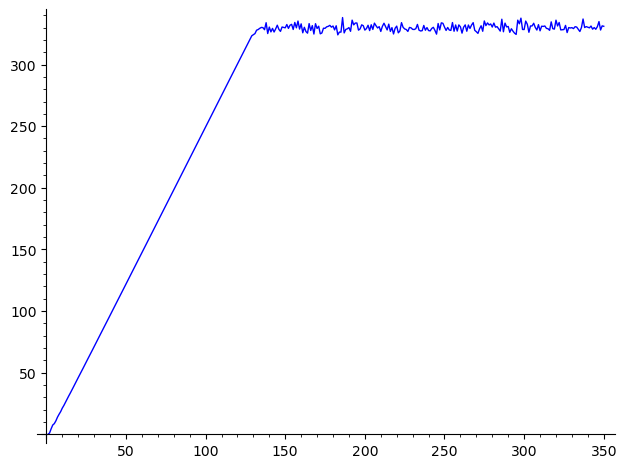

LOGS MINIMUM MODULI


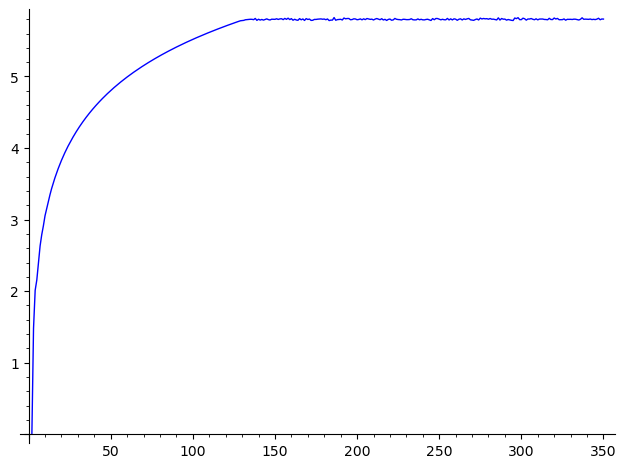

minimum logarithm of minimum modulus: 0.00000000000000000000000000000


In [3]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time
start=time.time()
# Increase PARI stack size to handle large polynomial root computations
pari.allocatemem(7*10^9)  # Allocate 7GB for PARI stack

def tau(n):
    def step1(n, k):
        return 35*k^4 - 52*k^3*n + 18*k^2*n^2
    def step2(n, k):
        return sigma(k) * sigma(n - k)
    def step3(n):
        ans = 0
        for k in range(1, n):
            ans += step1(n, k) * step2(n, k)
        return 24*ans
    return n^4 * sigma(n) - step3(n)

def h(n):
    if n>0:
        return tau(n) # i.e., tauPrime(n)
    if n==0:
        return 1

tau_list =[] 
for k in range(1, 520):
    tau_list.append([k,tau(k)])
    if k%20==0:
        print(k)

with open('/Users/barrybrent/data2/run2april26no11.txt', 'wb') as wfile:
    pickle.dump(tau_list, wfile) #output snipped


h_list=[[0,1]]+tau_list 
j_list=[(0,0)] # <<<<<<<<<<<<<<<<<< c=0
for n in [1..500]:# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r][1] 
    j_n=n*h_list[n][1]-sm
    j_list.append((n,j_n))


with open('/Users/barrybrent/data2/run2april26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) #output snipped

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()


from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable
matrix_list=[]
charpol_list=[]
roots_list=[]
mins_list=[]
log_mins_list=[]
dets=[]
tests=[]
for n in range(1, 351):
    elapsed=(time.time()-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) ### DEFORMED
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    # compute absolute value for each root (before any conversion)
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        if minn>0:
            log_minn=log(minn)
            log_mins_list.append((n,log_minn))
        
        
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()
p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MINIMUM MODULI")
p.show()
mml=[pair[1] for pair in log_mins_list]
print("minimum logarithm of minimum modulus:",min(mml))
        


with open('/Users/barrybrent/data2/run2apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run2apr26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run2apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run1apr26no16.txt', 'wb') as wfile: ### lost
    pickle.dump(dets, wfile) #output snipped
    
with open('/Users/barrybrent/data2/run2apr26no17.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile) #output snipped